# Climate Field Reconstruction (CFR) Package Tutorial

Based on: Zhu et al. (2024), *GMD* 17, 3409–3431  
https://gmd.copernicus.org/articles/17/3409/2024/

**Data caching notes:**
- `ClimateField.fetch()` automatically caches large files under `./data/` and skips re-downloads if the file exists.
- `ProxyDatabase.fetch()` always re-downloads (files are ~1 MB), but cells below add an explicit local-file check.

## What is pseudoPAGES2k?

A *synthetic* proxy network derived from the **iCESM last-millennium simulation** (850–2005 CE). Instead of real proxy measurements it uses temperature values sampled at the PAGES 2k network locations, optionally with added noise. Because the true climate is known, this is ideal for benchmarking reconstruction methods.

Naming scheme: `pseudoPAGES2k/<model>_<SNR>_<assignment>`

| Part | Options | Meaning |
|---|---|---|
| model | `ppwn`, `tpwn` | pink-noise proxy or tree-ring proxy |
| SNR | `SNRinf`, `SNR10`, `SNR2`, `SNR1`, `SNR0.5`, `SNR0.25` | signal-to-noise ratio (inf = no noise added) |
| assignment | `rta`, `fta` | random or full target assignment |

## Contents
1. Discover available datasets
2. ProxyDatabase — load, explore, and map proxy records
3. ClimateField — work with gridded climate data
4. Proxy System Models (PSMs) — calibrate proxy–climate relationships
5. ReconJob — full pseudoproxy reconstruction
6. ReconRes — analyse and validate results
7. Noise sensitivity — compare SNRinf vs SNR1

---
## 0  Imports & version check

In [1]:
import os
import cfr
import numpy as np
import matplotlib.pyplot as plt

# Paths used throughout — defined once here so every section can reference them
os.makedirs('./data', exist_ok=True)
PROXY_CACHE      = './data/ppwn_SNRinf_rta.nc'
PROXY_CACHE_SNR1 = './data/ppwn_SNR1_rta.nc'
DATA_FILE        = './data/tas_sfc_Amon_iCESM_past1000historical_085001-200512.nc'

print('cfr version:', cfr.__version__)
print()
print('NOTE: run cells top-to-bottom — every section depends on variables defined above.')

cfr version: 2026.3.26

NOTE: run cells top-to-bottom — every section depends on variables defined above.


---
## 1  Discover available datasets

Call `fetch()` with no arguments to print all registered names.

In [2]:
print('=== Proxy databases ===')
cfr.ProxyDatabase().fetch()   # lists all valid keys

=== Proxy databases ===
>>> Choose one from the supported databases:
- PAGES2kv2
- pseudoPAGES2k/ppwn_SNRinf_rta
- pseudoPAGES2k/ppwn_SNR10_rta
- pseudoPAGES2k/ppwn_SNR2_rta
- pseudoPAGES2k/ppwn_SNR1_rta
- pseudoPAGES2k/ppwn_SNR0.5_rta
- pseudoPAGES2k/ppwn_SNR0.25_rta
- pseudoPAGES2k/ppwn_SNRinf_fta
- pseudoPAGES2k/ppwn_SNR10_fta
- pseudoPAGES2k/ppwn_SNR2_fta
- pseudoPAGES2k/ppwn_SNR1_fta
- pseudoPAGES2k/ppwn_SNR0.5_fta
- pseudoPAGES2k/ppwn_SNR0.25_fta
- pseudoPAGES2k/tpwn_SNR10_rta
- pseudoPAGES2k/tpwn_SNR2_rta
- pseudoPAGES2k/tpwn_SNR1_rta
- pseudoPAGES2k/tpwn_SNR0.5_rta
- pseudoPAGES2k/tpwn_SNR0.25_rta
- pseudoPAGES2k/tpwn_SNR10_fta
- pseudoPAGES2k/tpwn_SNR2_fta
- pseudoPAGES2k/tpwn_SNR1_fta
- pseudoPAGES2k/tpwn_SNR0.5_fta
- pseudoPAGES2k/tpwn_SNR0.25_fta


In [3]:
print('=== Climate fields ===')
cfr.ClimateField().fetch()    # lists all valid keys

=== Climate fields ===
>>> Choose one from the supported entries:
- iCESM_past1000historical/tas
- iCESM_past1000historical/pr
- iCESM_past1000historical/d18O
- iCESM_past1000historical/psl
- iCESM_past1000/tas
- iCESM_past1000/pr
- iCESM_past1000/d18O
- iCESM_past1000/psl
- gistemp1200_ERSSTv4
- gistemp1200_GHCNv4_ERSSTv5
- CRUTSv4.07/tas
- CRUTSv4.07/pr
- 20CRv3/tas
- 20CRv3/pr
- HadCRUTv5
- HadCRUT4.6_GraphEM
- GPCCv2020


---
## 2  ProxyDatabase

We use the **perfect pseudo-proxies** (`SNRinf` = no noise added).  
The file (~1 MB NetCDF) comes from GitHub. The cell below saves it locally so re-runs skip the download.

In [4]:
# PROXY_CACHE is defined in the imports cell (Section 0)
if os.path.exists(PROXY_CACHE):
    print(f'Loading from local cache:\n  {PROXY_CACHE}')
    pdb = cfr.ProxyDatabase().load_nc(PROXY_CACHE)
else:
    print('Downloading from GitHub (~1 MB) ...')
    pdb = cfr.ProxyDatabase().fetch('pseudoPAGES2k/ppwn_SNRinf_rta', verbose=True)
    pdb.to_nc(PROXY_CACHE)
    print(f'Cached at: {PROXY_CACHE}')

print(f'Loaded {len(pdb.records)} records')

Loading from local cache:
  ./data/ppwn_SNRinf_rta.nc
Loaded 558 records


In [5]:
print('Total records:', len(pdb.records))
print('Proxy types  :', list(set(pdb.type_list)))

Total records: 558
Proxy types  : ['tree.TRW', 'ice.d18O', 'coral.d18O', 'lake.varve_thickness', 'tree.MXD', 'coral.SrCa']


In [6]:
# Filter to coral records only
pdb_coral = pdb.filter(by='ptype', keys=['coral.d18O'])
print('Coral records:', len(pdb_coral.records))

Coral records: 67


In [7]:
# Inspect one record
pid = list(pdb.records.keys())[0]
rec = pdb.records[pid]
print('pid   :', pid)
print('ptype :', rec.ptype)
print(f'lat={rec.lat:.1f}  lon={rec.lon:.1f}')
print(f'Time: {rec.time.min():.0f} – {rec.time.max():.0f}')

pid   : NAm_153
ptype : tree.TRW
lat=52.7  lon=241.7
Time: 1563 – 1996


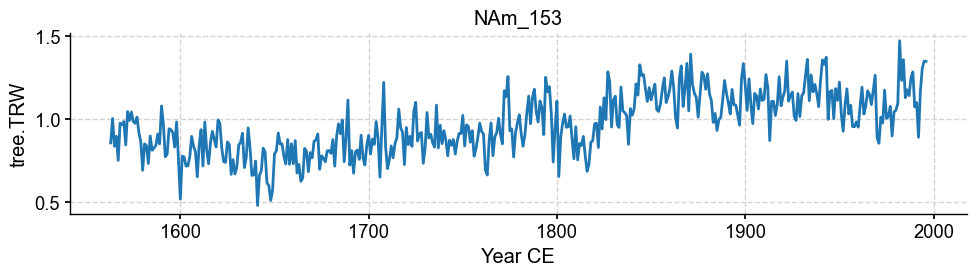

In [8]:
# Time-series plot of one record
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(rec.time, rec.value)
ax.set_xlabel('Year CE')
ax.set_ylabel(rec.ptype)
ax.set_title(pid)
plt.tight_layout()
plt.show()

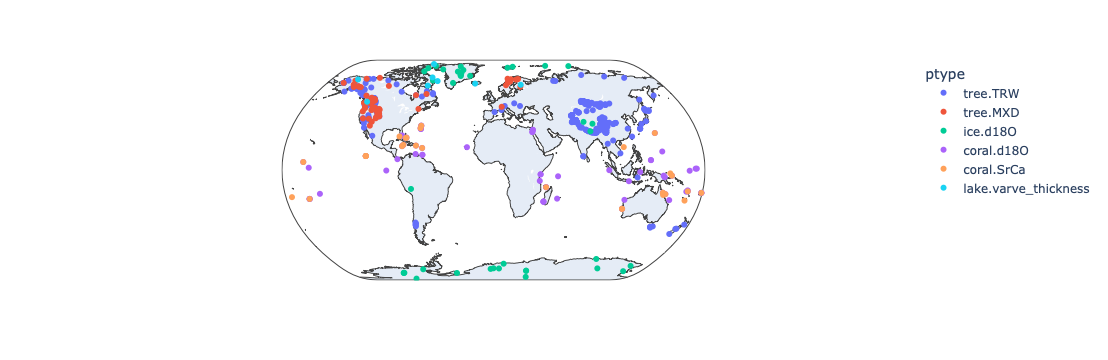

In [9]:
# pdb.plot() uses cartopy and can crash if the stock background image
# is too large. Use plotly_concise() for a lightweight interactive map,
# or a plain matplotlib scatter as a safe fallback.

# Option A: lightweight interactive map (no cartopy, no background image)
fig_plotly = pdb.plotly_concise()
fig_plotly.show()

# Option B: plain matplotlib scatter (always works, no cartopy dependency)
#lats = [r.lat for r in pdb.records.values()]
#lons = [r.lon for r in pdb.records.values()]
#ptypes = [r.ptype for r in pdb.records.values()]
#unique_types = list(set(ptypes))
#colors = {pt: f'C{i}' for i, pt in enumerate(unique_types)}
#
#fig, ax = plt.subplots(figsize=(12, 5))
#for pt in unique_types:
#    mask = [p == pt for p in ptypes]
#    ax.scatter([lons[i] for i, m in enumerate(mask) if m],
#               [lats[i] for i, m in enumerate(mask) if m],
#               s=15, label=pt, alpha=0.7)
#ax.set_xlabel('Longitude')
#ax.set_ylabel('Latitude')
#ax.set_title('pseudoPAGES2k proxy locations')
#ax.legend(fontsize=7, ncol=3)
#plt.tight_layout()
#plt.show()

---
## 3  ClimateField

`ClimateField` wraps gridded xarray data and provides spatial/temporal operations.

We use the **iCESM past1000historical** simulation — the same model that generated the pseudo-proxies.

> **Download: ~270 MB** — `ClimateField.fetch()` caches the file under `./data/` automatically and skips the download on subsequent calls.

In [10]:
# load=False uses lazy/dask loading — data is streamed from disk on demand
# instead of loading all 270 MB into RAM at once.
if os.path.exists(DATA_FILE):
    print(f'Loading from cache (lazy):\n  {DATA_FILE}')
    field = cfr.ClimateField().load_nc(DATA_FILE, vn='tas', load=False)
else:
    print('Downloading (~270 MB) ...')
    cfr.ClimateField().fetch('iCESM_past1000historical/tas', verbose=True)
    field = cfr.ClimateField().load_nc(DATA_FILE, vn='tas', load=False)
    print(f'Cached at: {DATA_FILE}')

print(field)
print('dims:', field.da.dims, '  shape:', field.da.shape)

Loading from cache (lazy):
  ./data/tas_sfc_Amon_iCESM_past1000historical_085001-200512.nc
dims: ('time', 'lat', 'lon')   shape: (13872, 96, 144)


<class 'cfr.v2024.ts.EnsTS'>


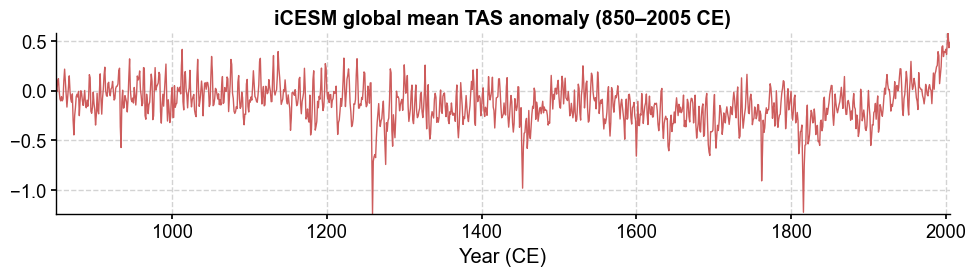

In [11]:
# Global mean temperature anomaly time series
#
# IMPORTANT ordering:
#   get_anom() MUST come BEFORE annualize().
#   After annualize() the time axis becomes plain integers (year numbers);
#   get_anom() then fails because it calls groupby('time.month') on integers.
#
# geo_mean() is the correct method — globalmean() does not exist.
# geo_mean() returns an EnsTS object; plot with .plot(), not .da.plot().

gmt = field.get_anom(ref_period=[1951, 1980]).annualize().geo_mean()
print(type(gmt))

fig, ax = gmt.plot(
    title='iCESM global mean TAS anomaly (850–2005 CE)',
    figsize=(10, 3),
)
plt.tight_layout()
plt.show()

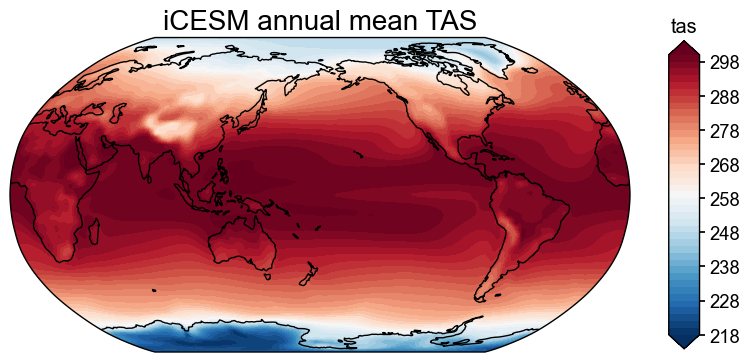

In [12]:
# Spatial mean map (time-averaged)
fig, ax = field.annualize().plot(title='iCESM annual mean TAS')
plt.show()

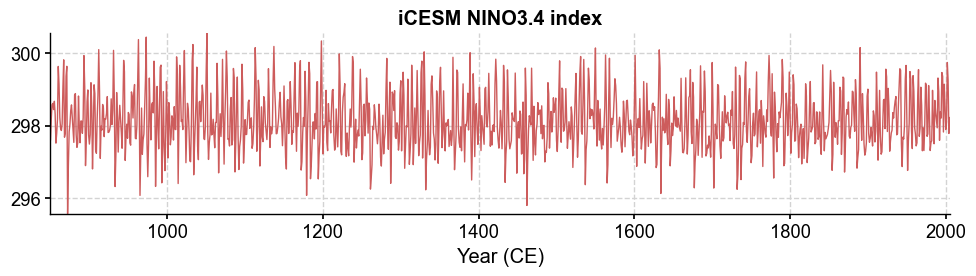

In [13]:
# Built-in climate indices
nino34 = field.annualize().index('nino3.4')
fig, ax = nino34.plot(title='iCESM NINO3.4 index', figsize=(10, 3))
plt.tight_layout()
plt.show()

---
## 4  Proxy System Models (PSMs)

A PSM maps climate → proxy values.

**Correct API pattern:**
1. `rec.get_clim(field, tag='obs')` — attach monthly climate to the proxy record (nearest-neighbour lookup); used by `calibrate()`
2. `rec.get_clim(field, tag='model')` — same data but stored under the `model` key; used by `forward()`
3. `psm = cfr.psm.Linear(pobj=rec)` — PSM is bound to the record, **not** constructed from `ptype`
4. `psm.calibrate()` — fits OLS using `rec.clim['obs.tas']`; no positional arguments
5. `psm.forward()` — predicts proxy from `rec.clim['model.tas']`; returns a **ProxyRecord** (not an array)

In [14]:
# Available PSM classes
print([name for name in dir(cfr.psm) if not name.startswith('_')])

['Bilinear', 'Coral_SrCa', 'Coral_d18O', 'Ice_d18O', 'Lake_VarveThickness', 'Linear', 'ProxyRecord', 'TempPlusNoise', 'VSLite', 'clean_df', 'cpu_count', 'datetime', 'integrate', 'np', 'pd', 'signal', 'smf', 'stats', 'tqdm', 'utils']


In [15]:
# Choose a record and attach the climate field under both tags
pid0 = list(pdb.records.keys())[0]
rec0 = pdb.records[pid0]

rec0.get_clim(field, tag='obs',   verbose=True)   # for calibrate()
rec0.get_clim(field, tag='model', verbose=True)   # for forward()

print('Climate keys on rec0:', list(rec0.clim.keys()))

NAm_153 >>> ProxyRecord.clim["obs.tas"] created.
NAm_153 >>> ProxyRecord.clim["model.tas"] created.
Climate keys on rec0: ['obs.tas', 'model.tas']


In [16]:
# Create and calibrate
psm = cfr.psm.Linear(pobj=rec0)   # pobj=, NOT ptype=
psm.calibrate()                    # no arguments — uses rec0.clim['obs.tas']

print(f"R² (adj) : {psm.calib_details['fitR2adj']:.4f}")
print(f"Slope    : {psm.model.params['tas']:.4f}")
print(f"Intercept: {psm.model.params['Intercept']:.4f}")
print(f"N obs    : {psm.calib_details['nobs']:.0f}")

R² (adj) : 0.1742
Slope    : 0.0770
Intercept: -20.0555
N obs    : 434


<class 'cfr.v2024.proxy.ProxyRecord'>


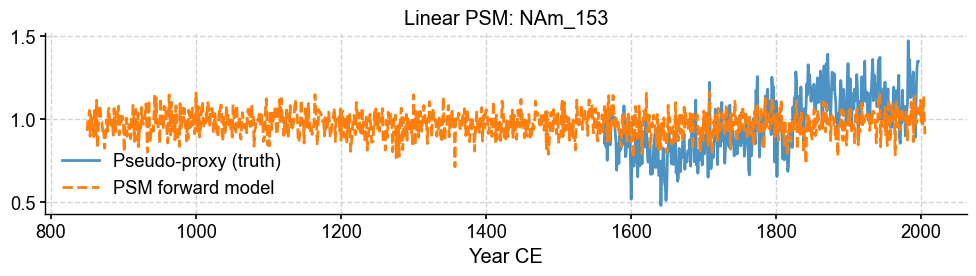

In [17]:
# Forward model — returns a ProxyRecord, access .time and .value
pp = psm.forward()   # uses rec0.clim['model.tas']
print(type(pp))

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(rec0.time, rec0.value, label='Pseudo-proxy (truth)', alpha=0.8)
ax.plot(pp.time,   pp.value,   label='PSM forward model',    linestyle='--')
ax.set_xlabel('Year CE')
ax.legend()
ax.set_title(f'Linear PSM: {pid0}')
plt.tight_layout()
plt.show()

---
## 5  Full Reconstruction with ReconJob

`ReconJob` orchestrates the complete workflow.

**Common pitfalls:**
- `load_clim` requires `path_dict` (a dict of `{variable_name: file_path}`) **and** `anom_period`
- PSM calibration is `calib_psms()` — **not** `calibrate_psms()` (that method doesn't exist)
- One Monte-Carlo seed is enough for a quick demo; use `list(range(20))` for a real run

In [18]:
job = cfr.ReconJob()

job.load_proxydb(PROXY_CACHE if os.path.exists(PROXY_CACHE)
                 else 'pseudoPAGES2k/ppwn_SNRinf_rta',
                 verbose=True)

# load=True: read everything into RAM now so the EnKF doesn't stall on lazy disk reads
job.load_clim(tag='prior', path_dict={'tas': DATA_FILE}, anom_period=[1951, 1980], load=True, verbose=True)
job.load_clim(tag='obs',   path_dict={'tas': DATA_FILE}, anom_period=[1951, 1980], load=True, verbose=True)

# Regrid to a coarser 24×48 grid (~7.5°×7.5°) — reduces spatial points from 13 824 to 1152,
# making the EnKF matrix operations ~12× faster and much lighter on RAM.
job.regrid_clim(tag='prior', nlat=24, nlon=48, verbose=True)
job.regrid_clim(tag='obs',   nlat=24, nlon=48, verbose=True)

>>> job.configs["proxydb_path"] = ./data/ppwn_SNRinf_rta.nc
>>> 558 records loaded
>>> job.proxydb created
>>> job.configs["prior_path"] = {'tas': './data/tas_sfc_Amon_iCESM_past1000historical_085001-200512.nc'}
>>> job.configs["prior_anom_period"] = [1951, 1980]
>>> job.configs["prior_lat_name"] = lat
>>> job.configs["prior_lon_name"] = lon
>>> job.configs["prior_time_name"] = time
>>> prior variables ['tas'] loaded
>>> job.prior created
>>> job.configs["obs_path"] = {'tas': './data/tas_sfc_Amon_iCESM_past1000historical_085001-200512.nc'}
>>> job.configs["obs_anom_period"] = [1951, 1980]
>>> job.configs["obs_lat_name"] = lat
>>> job.configs["obs_lon_name"] = lon
>>> job.configs["obs_time_name"] = time
>>> obs variables ['tas'] loaded
>>> job.obs created
>>> job.configs["prior_regrid_nlat"] = 24
>>> job.configs["prior_regrid_nlon"] = 48
>>> Processing tas ...
>>> job.configs["obs_regrid_nlat"] = 24
>>> job.configs["obs_regrid_nlon"] = 48
>>> Processing tas ...


In [19]:
# Step 1: calibrate PSMs against monthly obs (seasonal regression needs monthly data)
job.calib_psms(verbose=True)

# Step 2: forward PSMs — attaches monthly prior to each proxy record and creates
# pobj.pseudo (the model-estimated proxy series the EnKF uses as its observation operator)
job.forward_psms(verbose=True)

# Step 3: annualize — converts cftime monthly time axes to integer annual years,
# required by the EnKF time comparison inside run_da_mc
job.annualize_clim(tag='prior', verbose=True)
job.annualize_clim(tag='obs',   verbose=True)

>>> job.configs["ptype_psm_dict"] = {'tree.TRW': 'Linear', 'ice.d18O': 'Linear', 'coral.d18O': 'Linear', 'lake.varve_thickness': 'Linear', 'tree.MXD': 'Linear', 'coral.SrCa': 'Linear'}
>>> job.configs["ptype_season_dict"] = {'tree.TRW': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 'ice.d18O': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 'coral.d18O': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 'lake.varve_thickness': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 'tree.MXD': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], 'coral.SrCa': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]}
>>> job.configs["ptype_clim_dict"] = {'tree.TRW': ['tas'], 'ice.d18O': ['tas'], 'coral.d18O': ['tas'], 'lake.varve_thickness': ['tas'], 'tree.MXD': ['tas'], 'coral.SrCa': ['tas']}
>>> job.configs["psm_calib_period"] = [1850, 2015]


Calibrating the PSMs:  13%|████████████▎                                                                                | 74/558 [00:05<00:40, 11.99it/s]

The number of overlapped data points is 15 < 25. Skipping ...


Calibrating the PSMs:  15%|██████████████                                                                               | 84/558 [00:06<00:36, 12.90it/s]

The number of overlapped data points is 23 < 25. Skipping ...


...

The number of overlapped data points is 8 < 25. Skipping ...


Calibrating the PSMs: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 558/558 [00:43<00:00, 12.90it/s]


The number of overlapped data points is 0 < 25. Skipping ...
>>> PSM for Asi_243 failed to be calibrated.
>>> PSM for Ocn_144 failed to be calibrated.
>>> PSM for Ant_022 failed to be calibrated.
>>> PSM for Ocn_145 failed to be calibrated.
>>> PSM for Ocn_138 failed to be calibrated.
>>> PSM for Arc_045 failed to be calibrated.
>>> PSM for Asi_238 failed to be calibrated.
>>> PSM for Ant_016 failed to be calibrated.
>>> PSM for Ant_015 failed to be calibrated.
>>> PSM for Ant_014 failed to be calibrated.
>>> PSM for Arc_014 failed to be calibrated.
>>> 547 records tagged "calibrated" with ProxyRecord.psm created
>>> job.configs["ptype_forward_dict"] = {}


Forwarding the PSMs: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 547/547 [00:40<00:00, 13.40it/s]


>>> ProxyRecord.pseudo created for 547 records
>>> job.configs["prior_annualize_months"] = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
>>> Processing tas ...
>>> job.prior updated
>>> job.configs["obs_annualize_months"] = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
>>> Processing tas ...
>>> job.obs updated


In [30]:
# nens=20 keeps RAM usage manageable (default is 100, which needs ~6 GB).
# Increase nens for a real experiment once you know memory allows it.
save_dir = './recons/pseudo_snrinf'
os.makedirs(save_dir, exist_ok=True)

job.run_da_mc(
    save_dirpath=save_dir,
    recon_seeds=[0],
    recon_period=[850, 2000],
    nens=20,
    verbose=True,
)

>>> job.configs["recon_period"] = [850, 2000]
>>> job.configs["nens"] = 20
>>> job.configs["recon_seeds"] = [0]
>>> job.configs["save_dirpath"] = ./recons/pseudo_snrinf
>>> seed: 0 | max: 0


KF updating: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 1151/1151 [01:00<00:00, 19.17it/s]


>>> Reconstructed fields saved to: ./recons/pseudo_snrinf/job_r00_recon.nc
>>> DONE! Total time spent: 1.01 mins.


---
## 6  Analysing Results with ReconRes

**Common pitfalls:**
- `res.load(vn_list)` requires an **explicit list** of variable names to load — `verbose` is not accepted as the first positional argument
- Saved variables: `tas` (spatial field), `tas_gm` / `tas_nhm` / `tas_shm` (mean time series), `nino3.4`
- Methods `plot_gmt()`, `plot_skill()`, `calc_skill()` **do not exist**
- Use `res.recons['tas_gm'].plot()` for the time series and `res.valid()` + `res.plot_valid()` for skill

In [31]:
import glob

# Confirm output files exist before loading
recon_files = sorted(glob.glob(f'{save_dir}/job_r*_recon.nc'))
print(f'Found {len(recon_files)} reconstruction file(s):')
for f in recon_files: print(' ', f)

res = cfr.ReconRes(save_dir)

# Load only the global-mean time series first — fast and small.
# Load 'tas' (full spatial field) separately only when needed.
res.load(['tas_gm'], verbose=True)

Found 1 reconstruction file(s):
  ./recons/pseudo_snrinf/job_r00_recon.nc
>>> ReconRes.recons["tas_gm"] created
>>> ReconRes.da["tas_gm"] created


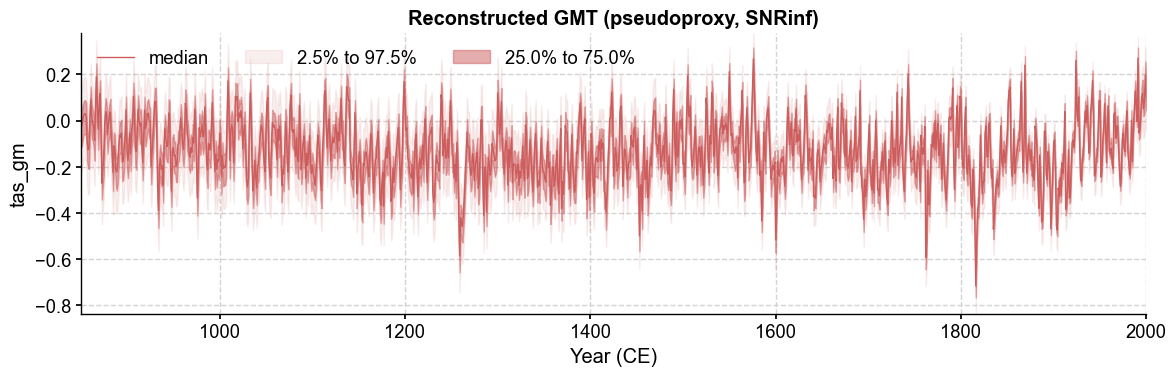

In [37]:
# Global mean temperature reconstruction
# plot_qs() shows the ensemble as median + quantile envelopes (2.5/25/75/97.5 %)
# instead of drawing all 20 individual members as separate red lines
fig, ax = res.recons['tas_gm'].plot_qs(
    title='Reconstructed GMT (pseudoproxy, SNRinf)',
    figsize=(12, 4),
)
plt.tight_layout()
plt.show()

In [33]:
# Compare reconstruction GMT against iCESM truth
# (field was loaded lazily in Section 3 — recompute truth GMT here)
truth_gmt = field.get_anom(ref_period=[1951, 1980]).annualize().geo_mean()

# Validate time series only (no full spatial 'tas' field needed)
res.valid(
    target_dict={'tas_gm': truth_gmt},
    stat=['corr', 'CE'],
    verbose=True,
)

>>> ReconRes.recons["tas_gm"] created
>>> ReconRes.da["tas_gm"] created
>>> Validating variable: tas_gm ...
>>> ReconRes.valid_ts[tas_gm] created


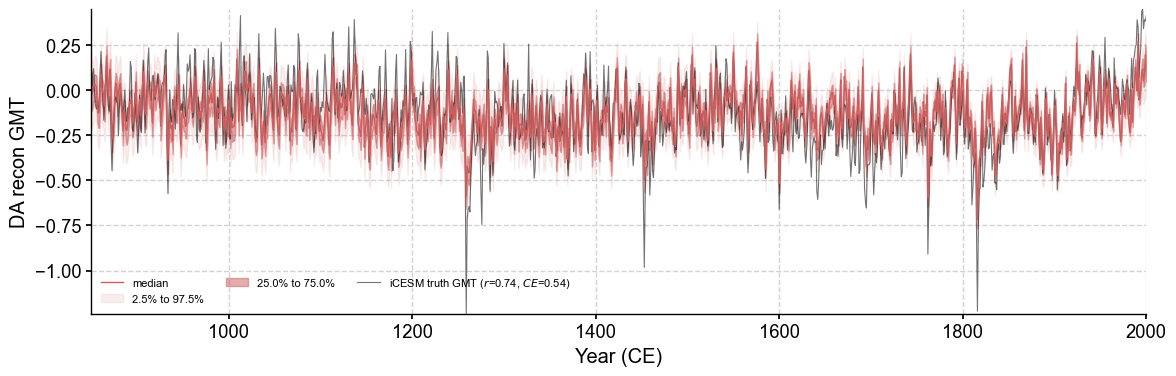

In [39]:
fig, ax_dict = res.plot_valid(
    recon_name_dict={'tas_gm': 'DA recon GMT'},
    target_name_dict={'tas_gm': 'iCESM truth GMT'},
)
ax = ax_dict['tas_gm']

# plot_qs() draws the reference line last with hardcoded solid black —
# make it thinner and semi-transparent so the ensemble bands stay visible
ref_line = ax.lines[-1]
ref_line.set_linewidth(0.8)
ref_line.set_alpha(0.55)
ref_line.set_zorder(1)   # behind the median line (default zorder 2)

# move legend below the dense upper-left area
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='lower left', ncol=3, fontsize=8)

plt.tight_layout()
plt.show()

---
## 7  Noise sensitivity experiment

Repeat with `SNR1` (signal-to-noise ratio = 1) to see how skill degrades.

In [ ]:
job2 = cfr.ReconJob()

if os.path.exists(PROXY_CACHE_SNR1):
    job2.load_proxydb(PROXY_CACHE_SNR1, verbose=False)
else:
    job2.load_proxydb('pseudoPAGES2k/ppwn_SNR1_rta', verbose=False)

job2.load_clim(tag='prior', path_dict={'tas': DATA_FILE}, anom_period=[1951, 1980], load=True)
job2.load_clim(tag='obs',   path_dict={'tas': DATA_FILE}, anom_period=[1951, 1980], load=True)
job2.regrid_clim(tag='prior', nlat=24, nlon=48)
job2.regrid_clim(tag='obs',   nlat=24, nlon=48)
job2.calib_psms()
job2.forward_psms()
job2.annualize_clim(tag='prior')
job2.annualize_clim(tag='obs')

save_dir2 = './recons/pseudo_snr1'
os.makedirs(save_dir2, exist_ok=True)
job2.run_da_mc(save_dirpath=save_dir2, recon_seeds=[0], recon_period=[850, 2000],
               nens=20, verbose=True)

Calibrating the PSMs:  13%|████████████▎                                                                                | 74/558 [00:05<00:37, 13.00it/s]

The number of overlapped data points is 15 < 25. Skipping ...


Calibrating the PSMs:  15%|██████████████                                                                               | 84/558 [00:06<00:36, 13.06it/s]

The number of overlapped data points is 23 < 25. Skipping ...


Calibrating the PSMs:  23%|█████████████████████▍                                                                      | 130/558 [00:10<00:32, 13.05it/s]

...

Calibrating the PSMs:  86%|██████████████████████████████████████████████████████████████████████████████▊             | 478/558 [00:37<00:07, 11.34it/s]

The number of overlapped data points is 8 < 25. Skipping ...


Calibrating the PSMs: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 558/558 [00:44<00:00, 12.67it/s]


The number of overlapped data points is 0 < 25. Skipping ...


Forwarding the PSMs:   8%|███████▉                                                                                      | 46/547 [00:03<00:36, 13.58it/s]

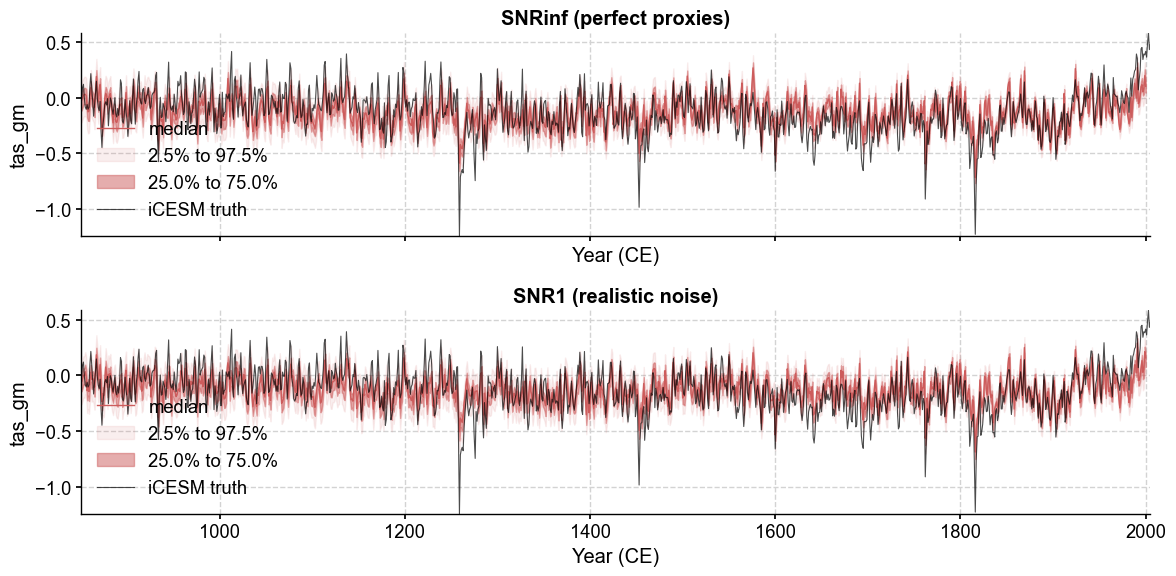

In [40]:
res2 = cfr.ReconRes(save_dir2)
res2.load(['tas_gm'])

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
res.recons['tas_gm'].plot_qs(title='SNRinf (perfect proxies)', ax=axes[0])
res2.recons['tas_gm'].plot_qs(title='SNR1 (realistic noise)',  ax=axes[1])
for ax in axes:
    ax.plot(truth_gmt.time, truth_gmt.value.squeeze(), color='k', lw=0.8,
            alpha=0.7, label='iCESM truth')
    ax.legend()
plt.tight_layout()
plt.show()

---
## 8  Next steps

| Topic | How |
|---|---|
| Real PAGES 2k proxies | `job.load_proxydb('PAGES2kv2')` |
| GraphEM algorithm | `pip install "cfr[graphem]"` → `job.run_graphem_mc(...)` |
| VSLite tree-ring PSM | `pip install "cfr[psm]"` → `job.calib_psms(ptype_psm_dict={'tree.TRW': 'VSLite'})` |
| Other climate fields | `cfr.ClimateField().fetch()` to list options |
| Full documentation | https://fzhu2e.github.io/cfr/v2024/ |
| Paper | Zhu et al. (2024), GMD 17, 3409–3431 |